<a href="https://colab.research.google.com/github/MaxHolikov/DataScience/blob/main/hw5/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
'''
#pip install kaggle
#https://www.kaggle.com/datasets/sarametawea/car-data
import get_dataset as gd
import logger as lg
from data_processing import DataProcessing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.impute import KNNImputer

lg.clear_log_file()
my_results_dict = {}

file_path='gcar_data.csv'
try:
    df = pd.read_csv(file_path)
    lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

processing= DataProcessing(df)
processing.print_file()
missing_values = processing.count_missing()   # количество пропущенных значений
processing.missing_report()

processing.del_model()                        # удаление излишних признаков

processing.col_to_numeric('year')
processing.col_to_numeric('price_in_euro')
processing.col_to_numeric('power_ps')
processing.consumption_to_numeric('fuel_consumption_l_100km')
processing.print_file()

missing_values = processing.count_missing()

processing.missing_report()

processing.remove_null_values()

processing.change_year()

missing_values = processing.count_missing()

processing.missing_report()

#матрица корреляции для понимания, чо делать с расходом топлива на электромобили(в датасете пропущены значения)
numeric_cols = ['age',
                'power_ps',
                'price_in_euro',
                'fuel_consumption_l_100km',
                'mileage_in_km']

data_num = processing.data[numeric_cols]
knn_imputer = KNNImputer(n_neighbors=5)
filled_data_knn = knn_imputer.fit_transform(data_num)
filled_data = pd.DataFrame(filled_data_knn, columns=numeric_cols)
correlation_matrix = filled_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation matrix')
plt.show()

# заполнение расхода электромобилей методом k-ближайших соседей, приведение к топливу
processing.impute_and_merge_consumption(n_neighbors=5)

missing_values = processing.count_missing()

processing.data.to_csv('cleaned_data.csv', index=False)   # сохранение отредактированных данных в файл
lg.log_event("INFO", "Оттредактированные данные сохранены в файл 'cleaned_data.csv'.")


if __name__ == "__main__":
    lg.read_log_file()
'''


'\n#pip install kaggle\n#https://www.kaggle.com/datasets/sarametawea/car-data\nimport get_dataset as gd\nimport logger as lg\nfrom data_processing import DataProcessing\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\nimport numpy as np\nfrom sklearn.impute import KNNImputer  \n\nlg.clear_log_file()\nmy_results_dict = {}\n\nfile_path=\'gcar_data.csv\'\ntry:\n    df = pd.read_csv(file_path)\n    lg.log_event("INFO", "File: .csv загружен" )\nexcept FileNotFoundError:\n    lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )\n\nprocessing= DataProcessing(df)\nprocessing.print_file()\nmissing_values = processing.count_missing()   # количество пропущенных значений\nprocessing.missing_report()\n\nprocessing.del_model()                        # удаление излишних признаков\n\nprocessing.col_to_numeric(\'year\')\nprocessing.col_to_numeric(\'price_in_euro\')\nprocessing.col_to_numeric(\'power_ps\')\nprocessing.consumption_to_numeric(\'fuel_consumption_l_100k

Лог-файл успешно очищен.


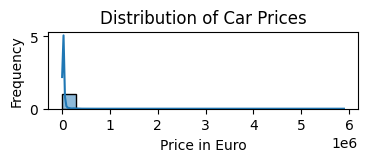

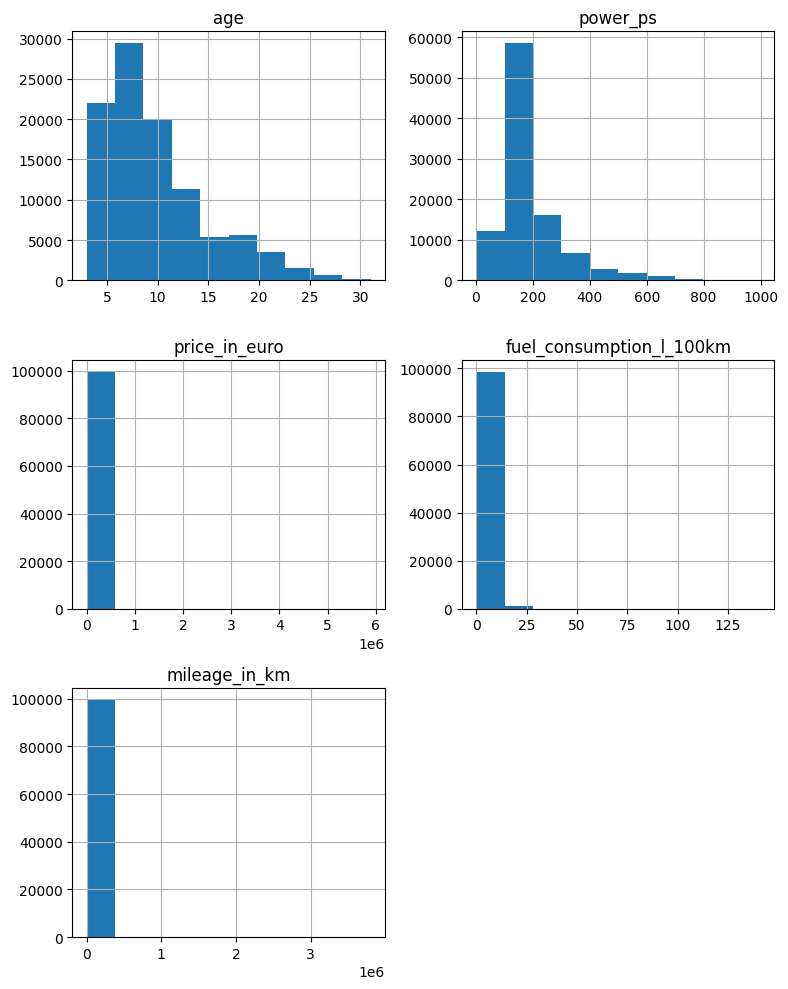

Содержимое лог-файла:
2026-03-06 00:37:05 - INFO - File: .csv загружен


In [9]:
import get_dataset as gd
import logger as lg
from data_processing import DataProcessing
from classification import Classification
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


numeric_cols = ['age',
                'power_ps',
                'price_in_euro',
                'fuel_consumption_l_100km',
                'mileage_in_km']


my_results_dict = {}
lg.clear_log_file()

file_path='cleaned_data.csv'
try:
  df = pd.read_csv(file_path)
  lg.log_event("INFO", "File: .csv загружен" )
except FileNotFoundError:
  lg.log_event("ERROR", "Cannot file: .csv! Load file: .csv!" )

def create_histogram(data, numeric_col, main_title, x_title):
    plt.figure(figsize=(4, 3))
    sns.histplot(data[numeric_col], bins=20, kde=True, stat='probability')
    plt.title(main_title)
    plt.xlabel(x_title)
    plt.ylabel('Frequency')
    plt.show()

def create_set_histogram(data, cols):
    data[cols].hist(bins=10, figsize=(8, 10))
    plt.tight_layout()
    plt.show()


create_histogram(df, 'price_in_euro', 'Distribution of Car Prices', 'Price in Euro')
create_set_histogram(df, numeric_cols)
'''
cl=Classification(df,results_dict=my_results_dict)

rez_grad_boost=cl.grad_boosting()

cl.ada_boosting()

cl.extra_trees()

cl.k_neighbors()

cl.dec_tree()

# Выводим подробную информацию о каждой модели
print("\n" + "="*70)
print("ДЕТАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("="*70)

model_keys = ['gradient_boosting', 'ada_boosting', 'ExtraTreesClassifier', 'KNeighborsClassifier', 'DecisionTreeClassifier']
for model_name in model_keys:
    if model_name in my_results_dict:
        model_data = my_results_dict[model_name]
        print(f"\n{model_name.upper()}:")
        print(f"   Accuracy: {model_data.get('accuracy', 'N/A'):.4f}")
        if 'model' in model_data:
            print(f"   Тип модели: {type(model_data['model']).__name__}")
        if 'report' in model_data:
            print("   Report:")  # Просто строка
            print(model_data['report'])  # Без отступа и f-string

# Сравнение всех моделей
print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)

comparison = {}
for model_name in my_results_dict:
    if isinstance(my_results_dict[model_name], dict) and 'accuracy' in my_results_dict[model_name]:
        comparison[model_name] = my_results_dict[model_name]['accuracy']

# Сортируем по точности
sorted_models = sorted(comparison.items(), key=lambda x: x[1], reverse=True)

print("\nРейтинг моделей по точности:")
for i, (model, acc) in enumerate(sorted_models, 1):
    medal = "1" if i == 1 else "2" if i == 2 else "3" if i == 3 else "4" if i == 4 else "5"
    print(f"{medal} {i}. {model}: {acc:.4f}")

# Сохраняем лучшую модель
if sorted_models:
    best_model_name = sorted_models[0][0]
    best_accuracy = sorted_models[0][1]
    print(f"\n Лучшая модель: {best_model_name} с точностью {best_accuracy:.4f}")

# ============= ВИЗУАЛИЗАЦИЯ =============
print("\n" + "="*70)
print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
print("="*70)

# 1. Столбчатая диаграмма сравнения моделей
plt.figure(figsize=(12, 6))
models = [m[0] for m in sorted_models]
accuracies = [m[1] for m in sorted_models]

# Цвета: лучшая модель - зеленый, остальные - синий
colors = ['green' if i == 0 else 'blue' for i in range(len(models))]
bars = plt.bar(models, accuracies, color=colors, alpha=0.7)

# Добавляем значения на столбцы
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Модели', fontsize=12)
plt.ylabel('Точность (Accuracy)', fontsize=12)
plt.title('Сравнение точности моделей классификации', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Круговая диаграмма для лучшей модели
if best_model_name in my_results_dict:
    best_model_data = my_results_dict[best_model_name]
    y_test = best_model_data['y_test']
    y_pred = best_model_data['y_pred']

    # Создаем фигуру с двумя подграфиками
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 2.1 Круговая диаграмма распределения классов
    unique, counts = np.unique(y_test, return_counts=True)
    axes[0].pie(counts, labels=[f'Класс {int(u)}' for u in unique],
                autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
    axes[0].set_title('Распределение классов в тестовой выборке', fontsize=12)

    # 2.2 Круговая диаграмма правильных/неправильных предсказаний
    correct = sum(y_test == y_pred)
    incorrect = len(y_test) - correct
    axes[1].pie([correct, incorrect], labels=['Правильные', 'Неправильные'],
                autopct='%1.1f%%', startangle=90, colors=['lightgreen', 'salmon'])
    axes[1].set_title(f'Точность предсказаний: {best_accuracy:.4f}', fontsize=12)

    plt.suptitle(f'Анализ лучшей модели: {best_model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 3. Матрицы ошибок для всех моделей (по желанию)
print("\nМатрицы ошибок для всех моделей:")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (model_name, model_data) in enumerate(my_results_dict.items()):
    if idx < 5 and isinstance(model_data, dict) and 'y_test' in model_data and 'y_pred' in model_data:
        from sklearn.metrics import confusion_matrix

        cm = confusion_matrix(model_data['y_test'], model_data['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
        axes[idx].set_title(f'{model_name}\nAccuracy: {model_data["accuracy"]:.4f}')
        axes[idx].set_xlabel('Предсказано')
        axes[idx].set_ylabel('Реально')

# Скрываем лишний подграфик
for i in range(len(my_results_dict), 6):
    axes[i].axis('off')

plt.suptitle('Матрицы ошибок для всех моделей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. График сравнения всех метрик (если есть дополнительные метрики)
try:
    from sklearn.metrics import precision_score, recall_score, f1_score

    metrics_comparison = {}
    for model_name, model_data in my_results_dict.items():
        if isinstance(model_data, dict) and 'y_test' in model_data and 'y_pred' in model_data:
            y_test = model_data['y_test']
            y_pred = model_data['y_pred']

            metrics_comparison[model_name] = {
                'Accuracy': model_data['accuracy'],
                'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
                'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
                'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
            }

    # Строим сравнительный график метрик
    if metrics_comparison:
        plt.figure(figsize=(14, 7))
        x = np.arange(len(metrics_comparison))
        width = 0.2
        multiplier = 0

        for metric, values in zip(['Accuracy', 'Precision', 'Recall', 'F1-score'],
                                  zip(*[m.values() for m in metrics_comparison.values()])):
            offset = width * multiplier
            plt.bar(x + offset, values, width, label=metric, alpha=0.8)
            multiplier += 1

        plt.xlabel('Модели', fontsize=12)
        plt.ylabel('Значение метрики', fontsize=12)
        plt.title('Сравнение метрик моделей', fontsize=14, fontweight='bold')
        plt.xticks(x + width * 1.5, metrics_comparison.keys(), rotation=45, ha='right')
        plt.legend(loc='lower right')
        plt.ylim(0, 1.0)
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
except:
    print("Дополнительные метрики не могут быть вычислены")

print("\n Визуализация завершена!")
'''
if __name__ == "__main__":
    lg.read_log_file()
